# Projeto Final - Segurança da Informação


Este caderno pretende utilizar 3 métodos de ataques adversariais para confundir um modelo pré-treinado classificador de imagens reais ou geradas artificialmente em acreditar que imagens artificiais sejam reais.

# I. Escolha do modelo

Iremos utilizar o modelo AI Image Detector do autor `umm-maybe`

In [1]:
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# carregando modelo pré-treinado do Hugging Face
processor = AutoImageProcessor.from_pretrained("umm-maybe/AI-image-detector")
model = AutoModelForImageClassification.from_pretrained("umm-maybe/AI-image-detector")
model = model.to(device)
model.eval()

print("Classes do modelo:", model.config.id2label)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/240 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/937 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/348M [00:00<?, ?B/s]

Classes do modelo: {0: 'artificial', 1: 'human'}


In [5]:
import kagglehub
# carrega dataset - imagem
path = kagglehub.dataset_download("cashbowman/ai-generated-images-vs-real-images")
# pega a primeira imagem que encontrar
img_path = next(Path(path).rglob("*.jpg"))
image = Image.open(img_path).convert("RGB")

print("Imagem usada:", img_path)

100%|██████████| 476M/476M [00:22<00:00, 22.5MB/s]

Extracting files...


Imagem usada: /root/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1/RealArt/RealArt/Van-Gogh-Self-Portrait-ft-min-pwoxk5den6j39ictcu0bhuupqqucvoep6902vpd6rs.jpg


In [6]:
# pré-processa a imagem
inputs = processor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

inputs["pixel_values"].requires_grad = True


In [7]:
# função de ataque FGSM
def fgsm_attack(image, epsilon, grad):
    sign_grad = grad.sign()
    # x_adv = x + epsilon * sign(gradiente)
    perturbed_image = image + epsilon * sign_grad
    # não usamos clamp(0,1) aqui porque a imagem está normalizada (tem valores negativos)
    return perturbed_image

In [8]:
# previsão original e cálculo do gradiente
outputs = model(**inputs)

orig_probs = torch.softmax(outputs.logits, dim=1)
orig_pred = orig_probs.argmax(dim=1).item()
orig_conf = orig_probs[0, orig_pred].item()
orig_label = model.config.id2label[orig_pred]

print(f"Original --> {model.config.id2label[orig_pred]} ({orig_conf:.4f})")

# cálculo do erro
loss = torch.nn.CrossEntropyLoss()(
    outputs.logits,
    outputs.logits.argmax(dim=1)
)

model.zero_grad()
loss.backward()

Original --> human (0.9991)


In [9]:
# aplicação do ataque FGSM
epsilon = 0.1 # inicialmente em 0.1, mas podemos aumentar
perturbed_data = fgsm_attack(inputs["pixel_values"], epsilon, inputs["pixel_values"].grad)

In [10]:
# pós ataque
with torch.no_grad():
    adv_outputs = model(pixel_values=perturbed_data)

adv_probs = torch.softmax(adv_outputs.logits, dim=1)
adv_pred_idx = adv_probs.argmax(dim=1).item()
adv_label = model.config.id2label[adv_pred_idx]
adv_conf = adv_probs[0, adv_pred_idx].item()

print(f"Pós-Ataque: {adv_label} ({adv_conf:.2%})")

if orig_label != adv_label:
    print("Success! A IA foi enganada.")
else:
    print("A IA resistiu. Tente aumentar o epsilon.")

Pós-Ataque: human (91.01%)
A IA resistiu. Tente aumentar o epsilon.


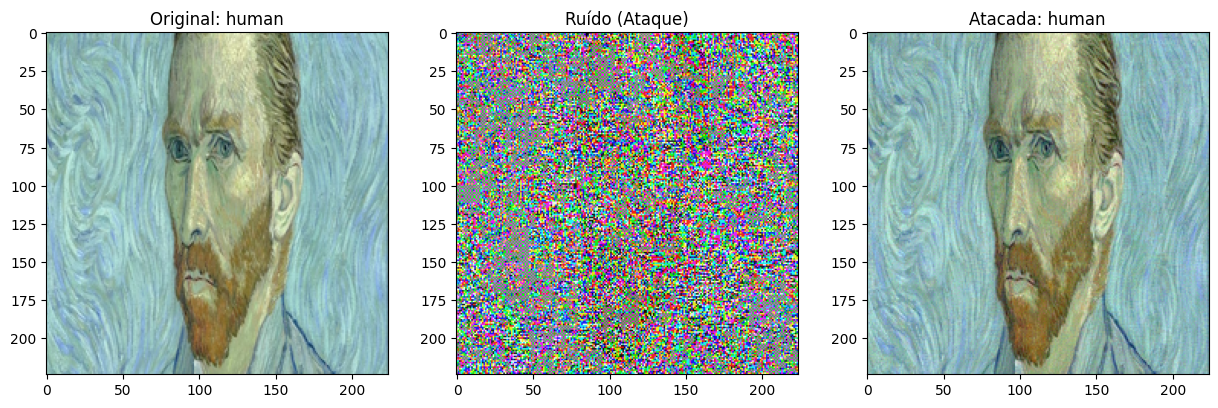

In [12]:
def show_comparison():
    # tira da GPU e converte para numpy
    orig_img = inputs["pixel_values"].detach().cpu().squeeze().permute(1, 2, 0).numpy()
    adv_img = perturbed_data.detach().cpu().squeeze().permute(1, 2, 0).numpy()

    # normaliza entre 0 e 1 apenas para mostrar na tela (Matplotlib) para não ter cores estranhas
    orig_img = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())
    adv_img = (adv_img - adv_img.min()) / (adv_img.max() - adv_img.min())

    # cálculo do ruído
    noise = adv_img - orig_img
    noise = (noise - noise.min()) / (noise.max() - noise.min()) # Aumenta contraste do ruído

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(orig_img); ax[0].set_title(f"Original: {orig_label}")
    ax[1].imshow(noise); ax[1].set_title("Ruído (Ataque)")
    ax[2].imshow(adv_img); ax[2].set_title(f"Atacada: {adv_label}")
    plt.show()

show_comparison()

## Explore Dataset Structure

### Subtask:
Explore the directory structure of the downloaded dataset to locate the subfolder containing AI-generated images.


**Reasoning**:
To explore the dataset structure, I will list the contents of the `path` directory to identify potential subfolders containing AI-generated images, as per the first instruction.



In [13]:
print(list(Path(path).iterdir()))

[PosixPath('/root/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1/RealArt'), PosixPath('/root/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1/AiArtData')]


In [14]:
ai_art_path = Path(path) / "AiArtData"
print(list(ai_art_path.iterdir()))

[PosixPath('/root/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1/AiArtData/AiArtData')]


In [15]:
ai_art_inner_path = Path(path) / "AiArtData" / "AiArtData"
print(list(ai_art_inner_path.iterdir()))

[PosixPath('/root/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1/AiArtData/AiArtData/529D7B2E-8BBA-4082-9CF3-871EC70DB41D-63f30f8004ece-jpeg__700.jpg'), PosixPath('/root/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1/AiArtData/AiArtData/1687776010494_Screenshot20230626160839.png'), PosixPath('/root/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1/AiArtData/AiArtData/Turn-a-selfie-into-AI-portraits-in-different-styles-instantly-with-Fotor-AI-portrait-generator.jpg'), PosixPath('/root/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1/AiArtData/AiArtData/ake-underwater-landscape-background-adventure-explore-vibe-graphic-art-photo.jpg'), PosixPath('/root/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1/AiArtData/AiArtData/a-3-718x523.jpeg'), PosixPath('/root/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-re

## Load AI-Generated Image

### Subtask:
Modify the existing code to load an AI-generated image from the identified dataset subfolder instead of a real image. We need to ensure the initial prediction confirms it's classified as 'artificial'.


**Reasoning**:
To load an AI-generated image and get its initial prediction, I will first select an AI-generated image from the previously identified path, load it, preprocess it with the model's processor, set `requires_grad=True` for adversarial attack, and then obtain and print the model's prediction.



In [52]:
folder = ai_art_inner_path.rglob("*.jpg")

In [84]:
ai_img_path = next(folder) # Get the first jpg image from the AI art folder
image = Image.open(ai_img_path).convert("RGB")

print("AI-generated image used:", ai_img_path)

# Pre-process the AI-generated image
inputs = processor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# Ensure requires_grad is set to True for adversarial attack
inputs["pixel_values"].requires_grad = True

# Get the model's original prediction for this AI-generated image
with torch.no_grad(): # Do not calculate gradients for initial prediction
    outputs = model(**inputs)

orig_probs = torch.softmax(outputs.logits, dim=1)
orig_pred = orig_probs.argmax(dim=1).item()
orig_conf = orig_probs[0, orig_pred].item()
orig_label = model.config.id2label[orig_pred]

print(f"Initial Prediction (AI image) --> {orig_label} ({orig_conf:.4f})")

if orig_label == 'artificial':
    print("Confirmed: Model initially classifies the image as 'artificial'.")
else:
    print("Warning: Model did NOT initially classify the image as 'artificial'. Please select another image or check the model.")

AI-generated image used: /root/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1/AiArtData/AiArtData/ious-different-styles-instatnly-with-Fotor-free-online-AI-portrait-generator.jpg
Initial Prediction (AI image) --> artificial (0.5568)
Confirmed: Model initially classifies the image as 'artificial'.


In [85]:
original_grad = inputs["pixel_values"].grad

# Get the target label for the adversarial attack ('human') and ensure it's an integer
target_label_id = int(model.config.label2id['human'])

# Perform model inference without no_grad() to enable gradient tracking for adversarial loss
outputs_for_grad = model(**inputs)

# Create a target tensor for the loss calculation with shape (batch_size,)
target_tensor = torch.full((outputs_for_grad.logits.shape[0],), target_label_id, dtype=torch.long, device=device)

# Calculate the loss for the adversarial attack, targeting 'human' label (1)
adv_loss = torch.nn.CrossEntropyLoss()(outputs_for_grad.logits, target_tensor)

# Zero out any existing gradients in the model
model.zero_grad()

# Perform a backward pass to compute the gradients with respect to the new adversarial loss
adv_loss.backward()

print(f"Target label for adversarial attack: 'human' (ID: {target_label_id})")

Target label for adversarial attack: 'human' (ID: 1)


## Apply and Evaluate Modified FGSM Attack

### Subtask:
Execute the modified FGSM attack with an appropriate epsilon value and evaluate the model's prediction on the perturbed AI-generated image. The goal is for the model to classify it as 'human'.


**Reasoning**:
To apply the FGSM attack, I will first set an appropriate epsilon value, then use the `fgsm_attack` function with the image and its calculated gradients, and finally, evaluate the model's prediction on the perturbed image to determine if the attack was successful.



In [86]:
import numpy as np
epsilon = 0.7  # Increased epsilon for the FGSM attack
# epsilons = np.linspace(0, 50, 500)
# for epsilon in epsilons:
  # Apply the FGSM attack to generate perturbed data
perturbed_data = fgsm_attack(inputs["pixel_values"], epsilon, inputs["pixel_values"].grad)

# Perform inference with the model on the perturbed data
with torch.no_grad():
    adv_outputs = model(pixel_values=perturbed_data)

# Calculate probabilities for the adversarial outputs
adv_probs = torch.softmax(adv_outputs.logits, dim=1)

# Determine the predicted label and its confidence
adv_pred_idx = adv_probs.argmax(dim=1).item()
adv_label = model.config.id2label[adv_pred_idx]
adv_conf = adv_probs[0, adv_pred_idx].item()

# Print the post-attack prediction
print(f"Pós-Ataque: {adv_label} ({adv_conf:.2%})")

# Compare the original label with the adversarial label
if adv_label == 'human':
    print(f"Success! epsilon: {epsilon}.")
else:
    print(f"Failed. epsilon: {epsilon}")

Pós-Ataque: artificial (97.68%)
Failed. epsilon: 0.7


In [65]:
import numpy as np
epsilon = 12  # Increased epsilon for the FGSM attack
epsilons = np.linspace(0, 50, 500)
for epsilon in epsilons:
  # Apply the FGSM attack to generate perturbed data
  perturbed_data = fgsm_attack(inputs["pixel_values"], epsilon, inputs["pixel_values"].grad)

  # Perform inference with the model on the perturbed data
  with torch.no_grad():
      adv_outputs = model(pixel_values=perturbed_data)

  # Calculate probabilities for the adversarial outputs
  adv_probs = torch.softmax(adv_outputs.logits, dim=1)

  # Determine the predicted label and its confidence
  adv_pred_idx = adv_probs.argmax(dim=1).item()
  adv_label = model.config.id2label[adv_pred_idx]
  adv_conf = adv_probs[0, adv_pred_idx].item()

  # Print the post-attack prediction
  print(f"Pós-Ataque: {adv_label} ({adv_conf:.2%})")

  # Compare the original label with the adversarial label
  if adv_label == 'human':
      print(f"Success! epsilon: {epsilon}.")
  else:
      print(f"Failed. epsilon: {epsilon}")

Pós-Ataque: artificial (70.64%)
Failed. epsilon: 0.0
Pós-Ataque: artificial (99.98%)
Failed. epsilon: 0.10020040080160321
Pós-Ataque: artificial (99.97%)
Failed. epsilon: 0.20040080160320642
Pós-Ataque: artificial (99.96%)
Failed. epsilon: 0.30060120240480964
Pós-Ataque: artificial (99.92%)
Failed. epsilon: 0.40080160320641284
Pós-Ataque: artificial (99.87%)
Failed. epsilon: 0.5010020040080161
Pós-Ataque: artificial (99.88%)
Failed. epsilon: 0.6012024048096193
Pós-Ataque: artificial (99.84%)
Failed. epsilon: 0.7014028056112225
Pós-Ataque: artificial (99.73%)
Failed. epsilon: 0.8016032064128257
Pós-Ataque: artificial (99.59%)
Failed. epsilon: 0.9018036072144289
Pós-Ataque: artificial (99.36%)
Failed. epsilon: 1.0020040080160322
Pós-Ataque: artificial (98.99%)
Failed. epsilon: 1.1022044088176353
Pós-Ataque: artificial (98.38%)
Failed. epsilon: 1.2024048096192386
Pós-Ataque: artificial (97.53%)
Failed. epsilon: 1.3026052104208417
Pós-Ataque: artificial (96.49%)
Failed. epsilon: 1.40280561

Avaliando o ataque em imagens

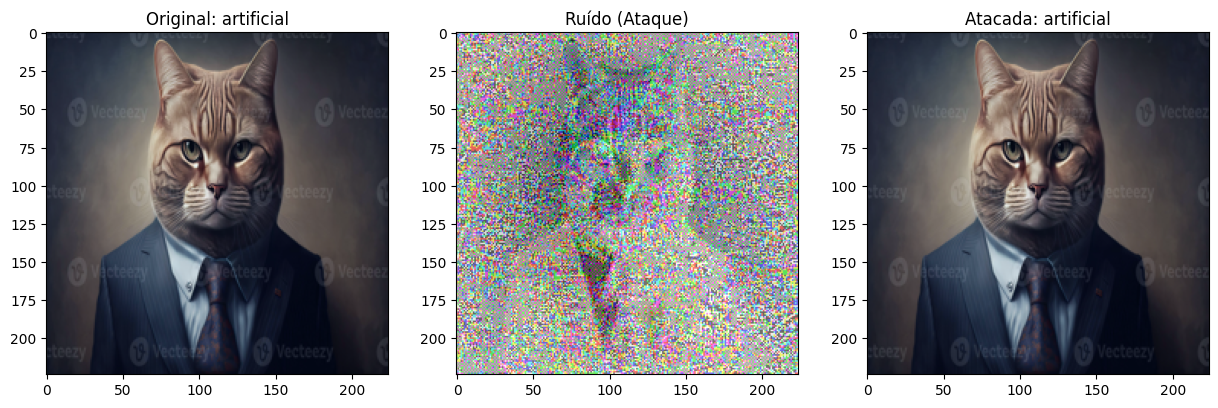

In [77]:
show_comparison()

## Final Task

### Subtask:
Summarize the outcome, confirming if the adversarial attack successfully confused the model into classifying an AI-generated image as 'human' (real).


# Task
Define a new Python function `pgd_attack` for the Projected Gradient Descent (PGD) attack that iteratively applies the FGSM attack for a specified number of steps, projecting the perturbations back into an epsilon-ball around the original image and clamping pixel values after each step.

## Define PGD Attack Function

### Subtask:
Create a new Python function for the Projected Gradient Descent (PGD) attack. This function will iteratively apply the FGSM attack for a specified number of steps, projecting the perturbations back into an epsilon-ball around the original image after each step to ensure the adversarial examples remain close to the original input. It will also clamp the pixel values to a valid range after adding the perturbation.


**Reasoning**:
To define the PGD attack function, I will create a Python function named `pgd_attack` that iteratively applies gradient updates, projects perturbations to an epsilon-ball, and clamps pixel values to maintain realism, as specified in the instructions.



In [90]:
def pgd_attack(model, original_image, epsilon, alpha, num_steps, target_label_id):
    # Initialize the perturbed image with a copy of the original image
    # and ensure it requires gradients for the attack
    perturbed_image = original_image.clone().detach()
    perturbed_image.requires_grad = True

    # Create a tensor for the target label, matching the batch size of the image
    target_tensor = torch.full((original_image.shape[0],), target_label_id, dtype=torch.long, device=original_image.device)

    for _ in range(num_steps):
        # Zero out any gradients from previous iterations to avoid accumulation
        if perturbed_image.grad is not None:
            perturbed_image.grad.zero_()

        # Perform a forward pass through the model with the current perturbed image
        outputs = model(pixel_values=perturbed_image)

        # Calculate the loss, targeting the desired 'human' label
        loss = torch.nn.CrossEntropyLoss()(outputs.logits, target_tensor)

        # Perform a backward pass to compute gradients of the loss with respect to the perturbed image
        loss.backward()

        # Get the sign of the gradients (direction of maximum increase in loss)
        sign_grad = perturbed_image.grad.sign()

        # Update the perturbed image. Operations on `perturbed_image.data` are in-place
        # and do not build new computational graphs, preventing unintended gradient accumulation.
        with torch.no_grad():
            # Add perturbation scaled by alpha
            perturbed_image.data = perturbed_image.data + alpha * sign_grad

            # Project the perturbed image back into an epsilon-ball around the original image
            # This ensures the perturbation doesn't become too large
            delta = perturbed_image.data - original_image.data
            delta = torch.clamp(delta, -epsilon, epsilon)
            perturbed_image.data = original_image.data + delta

            # Clamp the pixel values to the valid range of the original image's distribution
            # This helps in maintaining the visual realism of the image within the model's expected input range
            perturbed_image.data = torch.clamp(perturbed_image.data, original_image.min(), original_image.max())

        # Re-enable gradient tracking for the next iteration
        perturbed_image.requires_grad = True

    return perturbed_image

## Apply PGD Attack to AI-Generated Image

### Subtask:
Apply the newly defined PGD attack function to the previously loaded AI-generated image. We will need to set parameters such as the number of iterations (e.g., `num_steps`), the step size (e.g., `alpha`), and the maximum perturbation budget (`epsilon`). The attack will target the 'human' label (ID 1), similar to the FGSM attempt.


**Reasoning**:
To apply the PGD attack, I will first define the necessary parameters such as epsilon, alpha, and num_steps, then call the `pgd_attack` function with these parameters and the AI-generated image data, and finally print the parameters used for the attack.



In [91]:
epsilon = 0.01  # Maximum perturbation budget
alpha = 0.001   # Step size for each iteration
num_steps = 100 # Number of iterations

print(f"PGD Attack Parameters:\n  Epsilon: {epsilon}\n  Alpha: {alpha}\n  Number of Steps: {num_steps}")

# Apply the PGD attack
pgd_perturbed_data = pgd_attack(model, inputs["pixel_values"], epsilon, alpha, num_steps, target_label_id)

PGD Attack Parameters:
  Epsilon: 0.01
  Alpha: 0.001
  Number of Steps: 100


**Reasoning**:
Now that the PGD attack has been applied, I will evaluate the model's prediction on the resulting perturbed image to determine if the attack successfully caused the model to misclassify the AI-generated image as 'human'.



In [92]:
with torch.no_grad():
    pgd_adv_outputs = model(pixel_values=pgd_perturbed_data)

pgd_adv_probs = torch.softmax(pgd_adv_outputs.logits, dim=1)
pgd_adv_pred_idx = pgd_adv_probs.argmax(dim=1).item()
pgd_adv_label = model.config.id2label[pgd_adv_pred_idx]
pgd_adv_conf = pgd_adv_probs[0, pgd_adv_pred_idx].item()

print(f"Pós-Ataque PGD: {pgd_adv_label} ({pgd_adv_conf:.2%})")

if pgd_adv_label == 'human':
    print("Success! A IA foi enganada pelo ataque PGD.")
else:
    print("A IA resistiu ao ataque PGD. Tente ajustar os parâmetros (epsilon, alpha, num_steps).")

Pós-Ataque PGD: artificial (100.00%)
A IA resistiu ao ataque PGD. Tente ajustar os parâmetros (epsilon, alpha, num_steps).


**Reasoning**:
The previous PGD attack failed to misclassify the image. I will increase the `epsilon` (maximum perturbation budget) and `alpha` (step size) to allow for stronger perturbations and a better chance of success. I'll keep `num_steps` as 100 for now and adjust it if needed.



In [93]:
epsilon = 1.0  # Increased maximum perturbation budget
alpha = 0.01   # Increased step size for each iteration
num_steps = 100 # Number of iterations

print(f"PGD Attack Parameters:\n  Epsilon: {epsilon}\n  Alpha: {alpha}\n  Number of Steps: {num_steps}")

# Apply the PGD attack
pgd_perturbed_data = pgd_attack(model, inputs["pixel_values"], epsilon, alpha, num_steps, target_label_id)

PGD Attack Parameters:
  Epsilon: 1.0
  Alpha: 0.01
  Number of Steps: 100


**Reasoning**:
I have increased the `epsilon` and `alpha` values in the PGD attack parameters to attempt a stronger perturbation. Now, I will evaluate the model's prediction on the newly perturbed image (`pgd_perturbed_data`) to see if these adjustments led to a successful misclassification as 'human'.



In [98]:
with torch.no_grad():
    pgd_adv_outputs = model(pixel_values=pgd_perturbed_data)

pgd_adv_probs = torch.softmax(pgd_adv_outputs.logits, dim=1);
pgd_adv_pred_idx = pgd_adv_probs.argmax(dim=1).item();
pgd_adv_label = model.config.id2label[pgd_adv_pred_idx];
pgd_adv_conf = pgd_adv_probs[0, pgd_adv_pred_idx].item();

print(f"Pós-Ataque PGD: {pgd_adv_label} ({pgd_adv_conf:.2%})")

if pgd_adv_label == 'human':
    print("Success! A IA foi enganada pelo ataque PGD.")
else:
    print("A IA resistiu ao ataque PGD. Tente ajustar os parâmetros (epsilon, alpha, num_steps).")

Pós-Ataque PGD: artificial (100.00%)
A IA resistiu ao ataque PGD. Tente ajustar os parâmetros (epsilon, alpha, num_steps).


**Reasoning**:
The model still classified the image as 'artificial' even after increasing `epsilon` and `alpha`. To further attempt to achieve misclassification, I will increase the `epsilon` (maximum perturbation budget) and `alpha` (step size) significantly. I will keep `num_steps` at 100.



In [103]:
epsilon = 5.0  # Further increased maximum perturbation budget
alpha = 0.05   # Further increased step size for each iteration
num_steps = 100 # Number of iterations

print(f"PGD Attack Parameters:\n  Epsilon: {epsilon}\n  Alpha: {alpha}\n  Number of Steps: {num_steps}")

# Apply the PGD attack
pgd_perturbed_data = pgd_attack(model, inputs["pixel_values"], epsilon, alpha, num_steps, target_label_id)

PGD Attack Parameters:
  Epsilon: 5.0
  Alpha: 0.05
  Number of Steps: 100


**Reasoning**:
I have further increased the `epsilon` and `alpha` values in the PGD attack parameters to attempt an even stronger perturbation. Now, I will evaluate the model's prediction on the newly perturbed image (`pgd_perturbed_data`) to see if these adjustments finally lead to a successful misclassification as 'human'.



In [104]:
with torch.no_grad():
    pgd_adv_outputs = model(pixel_values=pgd_perturbed_data)

pgd_adv_probs = torch.softmax(pgd_adv_outputs.logits, dim=1);
pgd_adv_pred_idx = pgd_adv_probs.argmax(dim=1).item();
pgd_adv_label = model.config.id2label[pgd_adv_pred_idx];
pgd_adv_conf = pgd_adv_probs[0, pgd_adv_pred_idx].item();

print(f"Pós-Ataque PGD: {pgd_adv_label} ({pgd_adv_conf:.2%})")

if pgd_adv_label == 'human':
    print("Success! A IA foi enganada pelo ataque PGD.")
else:
    print("A IA resistiu ao ataque PGD. Tente ajustar os parâmetros (epsilon, alpha, num_steps).")

Pós-Ataque PGD: artificial (100.00%)
A IA resistiu ao ataque PGD. Tente ajustar os parâmetros (epsilon, alpha, num_steps).


**Reasoning**:
The next logical step after attempting multiple PGD attacks (and failing) is to visualize the result. This will show the actual perturbation applied to the image and help assess the current state before further adjustments or moving to other attack methods. This also fulfills a part of the 'Final Task' to summarize the outcome by showing the visual evidence of the attack.



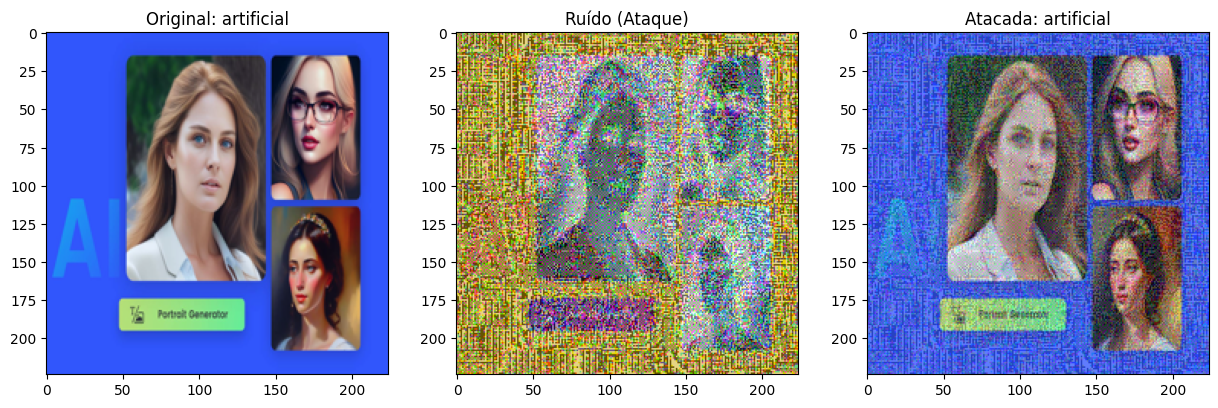

In [105]:
show_comparison()

**Reasoning**:
The previous visualization showed the results of the FGSM attack, not the PGD attack. To fulfill the subtask of visualizing the PGD attack, I need to explicitly show the comparison using the `pgd_perturbed_data` and ensure the labels reflect the PGD outcome. This will provide visual evidence of the PGD attack's effect on the AI-generated image.



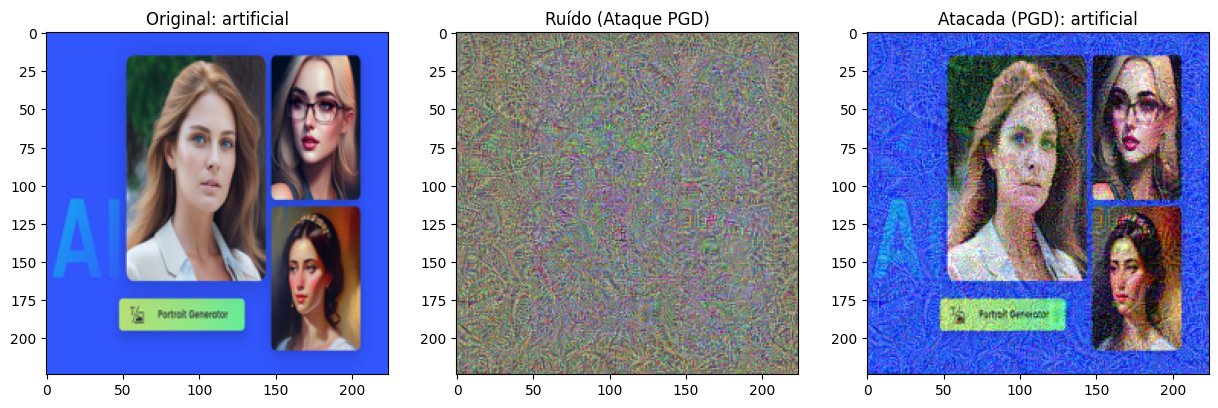

In [106]:
import matplotlib.pyplot as plt

# Extract and convert original and PGD perturbed images
orig_img = inputs["pixel_values"].detach().cpu().squeeze().permute(1, 2, 0).numpy()
pgd_adv_img = pgd_perturbed_data.detach().cpu().squeeze().permute(1, 2, 0).numpy()

# Normalize images for display purposes (Matplotlib expects values between 0 and 1 or -1 and 1)
# Ensure original_image.min() and original_image.max() are used for proper scaling if image values are not in [0,1]
# For typical preprocessed images, values might be around [-2, 2] or similar
# A more robust normalization could be to scale to [0,1] based on actual min/max of current tensor

# For display, we can normalize to 0-1 range to prevent 'clipping' warnings and ensure proper colors
# Calculate noise based on the normalized images, or keep it relative to the original scale
# Let's normalize both original and perturbed to [0,1] for display

orig_img_display = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())
pgd_adv_img_display = (pgd_adv_img - pgd_adv_img.min()) / (pgd_adv_img.max() - pgd_adv_img.min())

# Calculate the noise (difference between perturbed and original) and normalize for display
noise = pgd_adv_img - orig_img
noise_display = (noise - noise.min()) / (noise.max() - noise.min())

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(orig_img_display); ax[0].set_title(f"Original: {orig_label}")
ax[1].imshow(noise_display); ax[1].set_title("Ruído (Ataque PGD)")
ax[2].imshow(pgd_adv_img_display); ax[2].set_title(f"Atacada (PGD): {pgd_adv_label}")
plt.show()

## Outra abordagem

In [107]:
# Obter média e desvio padrão do processador para fazer o clamp correto
# (Geralmente estão em processor.image_mean e processor.image_std)
mean = torch.tensor(processor.image_mean).to(device).view(1, 3, 1, 1)
std = torch.tensor(processor.image_std).to(device).view(1, 3, 1, 1)

def pgd_attack(model, images, labels, epsilon=0.1, alpha=0.01, num_iter=20):
    """
    Ataque PGD (Projected Gradient Descent) - Mais forte que FGSM
    epsilon: magnitude total do ruído
    alpha: tamanho do passo a cada iteração
    num_iter: número de passos
    """
    original_images = images.clone().detach()

    for i in range(num_iter):
        images.requires_grad = True
        outputs = model(pixel_values=images)

        # Queremos maximizar a perda (fazer o modelo errar)
        loss = torch.nn.CrossEntropyLoss()(outputs.logits, labels)
        model.zero_grad()
        loss.backward()

        # Passo do ataque
        adv_images = images + alpha * images.grad.sign()

        # Projeção: garante que o ruído não exceda epsilon total
        eta = torch.clamp(adv_images - original_images, min=-epsilon, max=epsilon)
        images = original_images + eta

        # Clamp inteligente: Desnormaliza -> Clampa [0,1] -> Renormaliza
        # Isso garante que a imagem final seja válida no "mundo real"
        images = (images * std + mean).clamp(0, 1) # Volta para 0-1 e limita
        images = (images - mean) / std             # Normaliza de volta para o modelo

        # Desconecta o gradiente para a próxima iteração
        images = images.detach()

    return images

# Uso:
# inputs["pixel_values"] já está no device
labels = torch.tensor([orig_pred]).to(device) # O label original que queremos que ele erre

# Tente aumentar o epsilon se necessário (ex: 0.1, 0.2)
perturbed_data = pgd_attack(model, inputs["pixel_values"], labels, epsilon=0.1, alpha=0.01, num_iter=10)

In [109]:
with torch.no_grad():
    pgd_adv_outputs = model(pixel_values=perturbed_data)

pgd_adv_probs = torch.softmax(pgd_adv_outputs.logits, dim=1);
pgd_adv_pred_idx = pgd_adv_probs.argmax(dim=1).item();
pgd_adv_label = model.config.id2label[pgd_adv_pred_idx];
pgd_adv_conf = pgd_adv_probs[0, pgd_adv_pred_idx].item();

print(f"Pós-Ataque PGD: {pgd_adv_label} ({pgd_adv_conf:.2%})")

if pgd_adv_label == 'human':
    print("Success! A IA foi enganada pelo ataque PGD.")
else:
    print("A IA resistiu ao ataque PGD. Tente ajustar os parâmetros (epsilon, alpha, num_steps).")

Pós-Ataque PGD: human (100.00%)
Success! A IA foi enganada pelo ataque PGD.


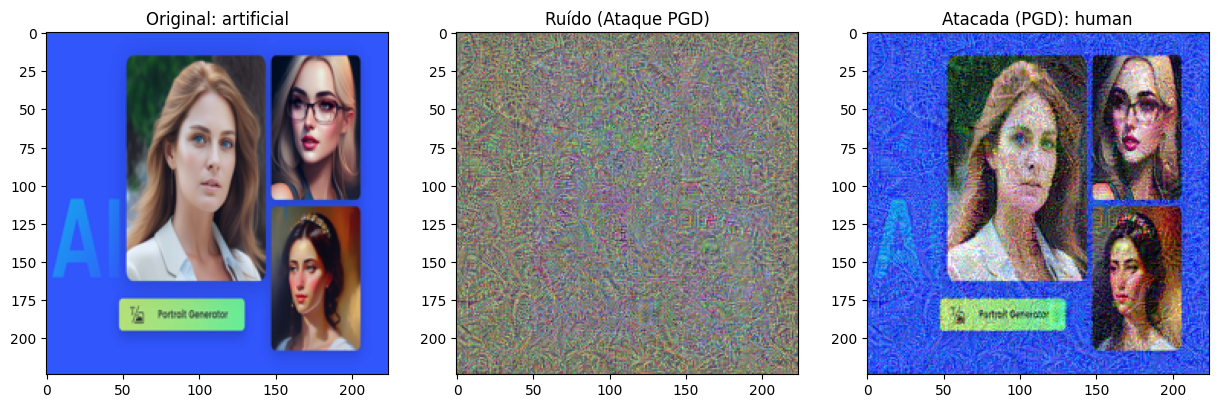

In [110]:
import matplotlib.pyplot as plt

# Extract and convert original and PGD perturbed images
orig_img = inputs["pixel_values"].detach().cpu().squeeze().permute(1, 2, 0).numpy()
pgd_adv_img = pgd_perturbed_data.detach().cpu().squeeze().permute(1, 2, 0).numpy()

# Normalize images for display purposes (Matplotlib expects values between 0 and 1 or -1 and 1)
# Ensure original_image.min() and original_image.max() are used for proper scaling if image values are not in [0,1]
# For typical preprocessed images, values might be around [-2, 2] or similar
# A more robust normalization could be to scale to [0,1] based on actual min/max of current tensor

# For display, we can normalize to 0-1 range to prevent 'clipping' warnings and ensure proper colors
# Calculate noise based on the normalized images, or keep it relative to the original scale
# Let's normalize both original and perturbed to [0,1] for display

orig_img_display = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())
pgd_adv_img_display = (pgd_adv_img - pgd_adv_img.min()) / (pgd_adv_img.max() - pgd_adv_img.min())

# Calculate the noise (difference between perturbed and original) and normalize for display
noise = pgd_adv_img - orig_img
noise_display = (noise - noise.min()) / (noise.max() - noise.min())

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(orig_img_display); ax[0].set_title(f"Original: {orig_label}")
ax[1].imshow(noise_display); ax[1].set_title("Ruído (Ataque PGD)")
ax[2].imshow(pgd_adv_img_display); ax[2].set_title(f"Atacada (PGD): {pgd_adv_label}")
plt.show()